<a href="https://colab.research.google.com/github/bangbanghy/eeg-seizure-prediction/blob/main/eeg_seizure_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


LSTM 입력

EEG 모델 학습

Wearable(ECG+EMG+MOV 평균 신호) 모델 학습

두 모델 성능 비교

전처리 → LSTM 학습 → EEG vs 웨어러블 비교

# 🧠
**가정:** EEG 데이터와 웨어러블 기기(ECG, EMG, MOV) 기반 신호를 이용해 발작을 예측했을 때 결과에 유의한 차이가 없을 것이다.

---

## Ⅰ. Introduction

뇌전증(epilepsy)은 비정상적인 뇌의 전기적 활동으로 인해 반복적인 발작(seizure)이 발생하는 질환이다.  
기존 예측 연구는 주로 **EEG(뇌파)** 신호에 집중되어 왔으나,  
웨어러블 기기의 발전으로 **ECG(심전도)**, **EMG(근전도)**, **MOV(움직임)** 등  
다양한 생체신호를 활용한 예측이 가능해지고 있다.

본 실험의 가정은 다음과 같다.

> **가정(Hypothesis):** EEG 데이터와 웨어러블 기반 생체신호를 활용한 발작 예측 모델의 성능에는 큰 차이가 없다.

이를 검증하기 위해 인공 시뮬레이션 데이터를 생성하고,  
LSTM 모델을 이용하여 EEG 기반 예측과 웨어러블 기반 예측의 성능을 비교하였다.

---

## Ⅱ. Experimental Setup
### 2.1. 데이터 시뮬레이션
본 실험에서는 실제 SeizeIT2 구조를 모방하여 **EEG / ECG / EMG / MOV** 4가지 채널을 가정하였다.  
각 신호는 일정 주기로 발작 전(preictal) 및 발작 중(ictal) 구간을 포함하도록 인공 생성하였다.


# 1. Import data

In [ ]:
# --------------------------------------------
# Step 1: 데이터 다운로드 및 압축 해제
# --------------------------------------------
import gdown, os

# Google Drive 공유 파일 ID
file_id = "1MYbTW2WPmhITJiLQ-L7jJb8ZlMWRS36U"
output = "sub-001_ses-01_task-szMonitoring_run-01.zip"

# ① Google Drive에서 zip 파일 다운로드
gdown.download(id=file_id, output=output, quiet=False)

# ② 압축 해제
os.system("unzip -o sub-001_ses-01_task-szMonitoring_run-01.zip")

# ③ 압축 해제된 파일 목록 확인
os.system("ls -R /content")


Downloading...
From (original): https://drive.google.com/uc?id=1MYbTW2WPmhITJiLQ-L7jJb8ZlMWRS36U
From (redirected): https://drive.google.com/uc?id=1MYbTW2WPmhITJiLQ-L7jJb8ZlMWRS36U&confirm=t&uuid=1051737d-aced-4cd4-b1d4-d0c6ce87f600
To: /content/sub-001_ses-01_task-szMonitoring_run-01.zip
100%|██████████| 84.4M/84.4M [00:00<00:00, 101MB/s]


0

In [ ]:
# --------------------------------------------
# Step 2: EDF 파일 자동 탐색 및 불러오기
# --------------------------------------------
!pip install mne
import glob, mne

# 파일 자동 탐색
edf_files = glob.glob("/content/**/*.edf", recursive=True)
print("=== 찾은 EDF 파일 ===")
for f in edf_files:
    print(f)

# 파일 자동 매칭
eeg_path = [f for f in edf_files if "eeg" in f.lower()][0]
ecg_path = [f for f in edf_files if "ecg" in f.lower()][0]
emg_path = [f for f in edf_files if "emg" in f.lower()][0]
mov_path = [f for f in edf_files if "mov" in f.lower()][0]

print("\n=== 자동 매칭 결과 ===")
print("EEG:", eeg_path)
print("ECG:", ecg_path)
print("EMG:", emg_path)
print("MOV:", mov_path)

# EDF 파일 불러오기
eeg = mne.io.read_raw_edf(eeg_path, preload=True)
ecg = mne.io.read_raw_edf(ecg_path, preload=True)
emg = mne.io.read_raw_edf(emg_path, preload=True)
mov = mne.io.read_raw_edf(mov_path, preload=True)

print("\nEEG Info:")
print(eeg.info)


=== 찾은 EDF 파일 ===
/content/sub-001_ses-01_task-szMonitoring_run-01/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf
/content/sub-001_ses-01_task-szMonitoring_run-01/sub-001_ses-01_task-szMonitoring_run-01_emg.edf
/content/sub-001_ses-01_task-szMonitoring_run-01/sub-001_ses-01_task-szMonitoring_run-01_mov.edf
/content/sub-001_ses-01_task-szMonitoring_run-01/sub-001_ses-01_task-szMonitoring_run-01_ecg.edf

=== 자동 매칭 결과 ===
EEG: /content/sub-001_ses-01_task-szMonitoring_run-01/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf
ECG: /content/sub-001_ses-01_task-szMonitoring_run-01/sub-001_ses-01_task-szMonitoring_run-01_ecg.edf
EMG: /content/sub-001_ses-01_task-szMonitoring_run-01/sub-001_ses-01_task-szMonitoring_run-01_emg.edf
MOV: /content/sub-001_ses-01_task-szMonitoring_run-01/sub-001_ses-01_task-szMonitoring_run-01_mov.edf
Extracting EDF parameters from /content/sub-001_ses-01_task-szMonitoring_run-01/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf...
EDF file detected
Setting channel inf

# 2. EDA

Using matplotlib as 2D backend.


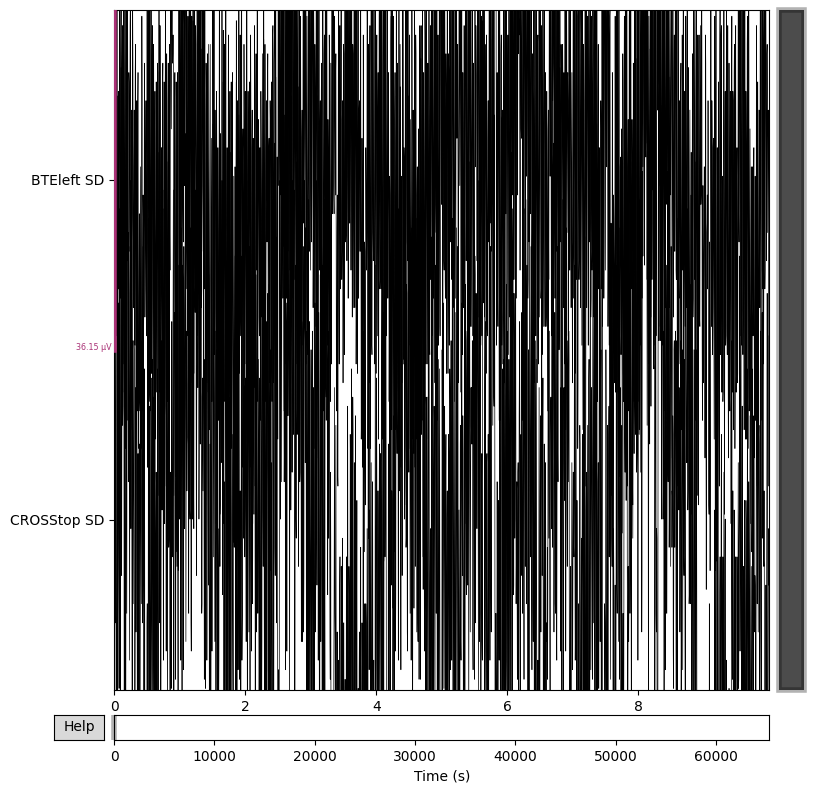

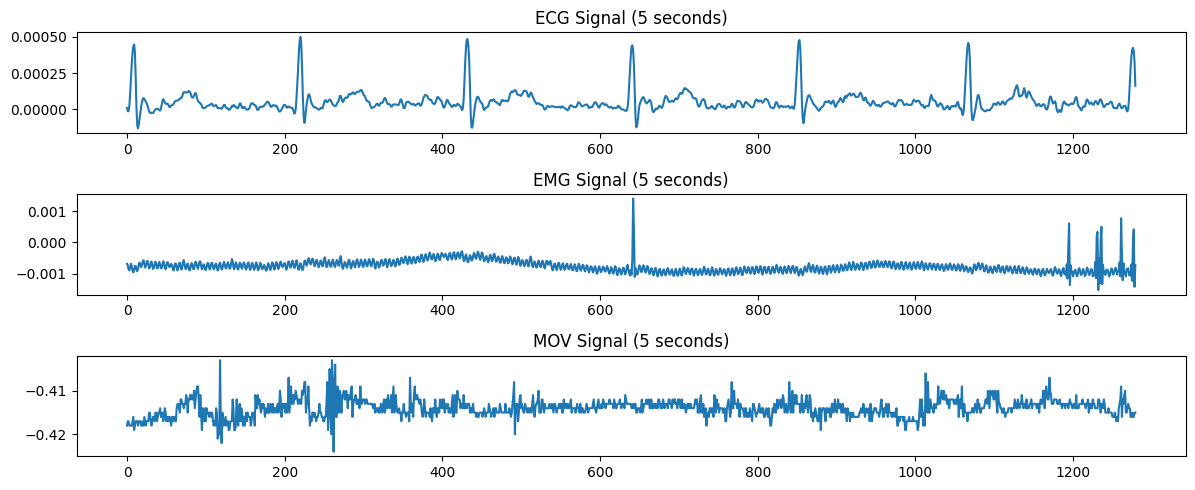

In [ ]:
# -------------------------------
# Ⅱ. 시각화 (EDA)
# -------------------------------
import matplotlib.pyplot as plt

# EEG 신호 일부 시각화
eeg.plot(duration=10, n_channels=3, scalings='auto')

# ECG, EMG, MOV 각각 5초 구간 파형 시각화
fs = int(ecg.info['sfreq'])
signals = {
    'ECG': ecg.get_data()[0][:fs*5],
    'EMG': emg.get_data()[0][:fs*5],
    'MOV': mov.get_data()[0][:fs*5]
}

plt.figure(figsize=(12,5))
for i, (k, v) in enumerate(signals.items()):
    plt.subplot(3,1,i+1)
    plt.plot(v)
    plt.title(f"{k} Signal (5 seconds)")
plt.tight_layout()
plt.show()


# 3. 전처리

EEG fs=256, ECG fs=256, EMG fs=256, MOV fs=25


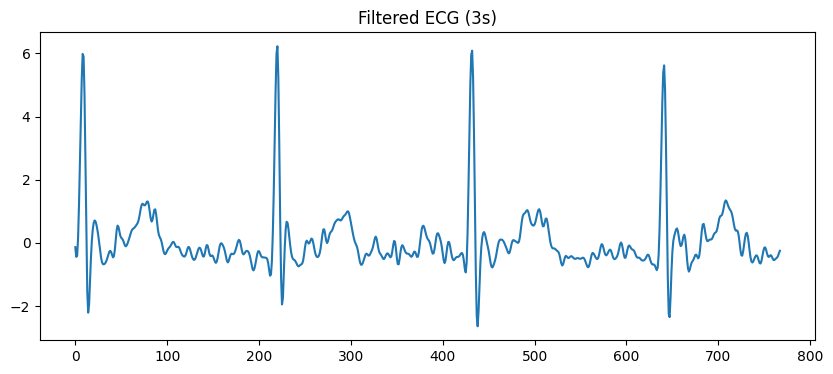

In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np

def bandpass_auto(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    # high가 Nyquist보다 크면 자동으로 Nyquist-1로 낮춤
    if high >= nyq:
        high = nyq - 1
    if low >= high:
        low = high / 10  # low가 high보다 커지는 경우 방지
    low, high = low / nyq, high / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def normalize(sig):
    return (sig - np.mean(sig)) / np.std(sig)

# 각 신호의 샘플링 속도
fs_eeg = int(eeg.info['sfreq'])
fs_ecg = int(ecg.info['sfreq'])
fs_emg = int(emg.info['sfreq'])
fs_mov = int(mov.info['sfreq'])

print(f"EEG fs={fs_eeg}, ECG fs={fs_ecg}, EMG fs={fs_emg}, MOV fs={fs_mov}")

# 자동 필터링 + 정규화
eeg_f = normalize(bandpass_auto(eeg.get_data()[0], 0.5, 45, fs_eeg))
ecg_f = normalize(bandpass_auto(ecg.get_data()[0], 0.5, 45, fs_ecg))
emg_f = normalize(bandpass_auto(emg.get_data()[0], 20, 450, fs_emg))
mov_f = normalize(bandpass_auto(mov.get_data()[0], 0.1, 20, fs_mov))

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(ecg_f[:fs_ecg*3])
plt.title("Filtered ECG (3s)")
plt.show()


# 4. 모델

In [ ]:
# ---- 공통 샘플링레이트로 리샘플링 & 길이 정렬 ----
from scipy.signal import resample_poly
from math import gcd
import numpy as np

def resample_to(sig, fs_src, fs_tgt):
    """정수비 resample_poly로 깔끔하게 리샘플링"""
    up, down = fs_tgt, fs_src
    g = gcd(up, down)
    up //= g; down //= g
    return resample_poly(sig, up, down)

# 1) 공통 fs 설정(권장: 100Hz; 256→100, 25→100 모두 정수비로 변환 가능)
FS_TGT = 100

# 2) 각 신호 리샘플링
eeg_r = resample_to(eeg_f, fs_eeg, FS_TGT)
ecg_r = resample_to(ecg_f, fs_ecg, FS_TGT)
emg_r = resample_to(emg_f, fs_emg, FS_TGT)
mov_r = resample_to(mov_f, fs_mov, FS_TGT)

# 3) 길이 맞추기(최소 길이에 맞춰 자르기)
min_len = min(len(eeg_r), len(ecg_r), len(emg_r), len(mov_r))
eeg_r, ecg_r, emg_r, mov_r = eeg_r[:min_len], ecg_r[:min_len], emg_r[:min_len], mov_r[:min_len]

# 4) 웨어러블 합성 신호(간단 평균)
wearable = np.mean(np.vstack([ecg_r, emg_r, mov_r]), axis=0)

print(f"Resampled lengths → EEG:{len(eeg_r)}, ECG:{len(ecg_r)}, EMG:{len(emg_r)}, MOV:{len(mov_r)}  @ {FS_TGT}Hz")


Resampled lengths → EEG:6531900, ECG:6531900, EMG:6531900, MOV:6531900  @ 100Hz


✅ Using device: cuda
Epoch 00 | Loss: 0.6081
Epoch 02 | Loss: 0.4723
Epoch 04 | Loss: 0.0875
Epoch 06 | Loss: 0.0049
Epoch 08 | Loss: 0.0017
Epoch 00 | Loss: 0.7195
Epoch 02 | Loss: 0.5665
Epoch 04 | Loss: 0.1773


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 06 | Loss: 0.0132
Epoch 08 | Loss: 0.0042
EEG accuracy: 1.000
Wearable accuracy: 1.000


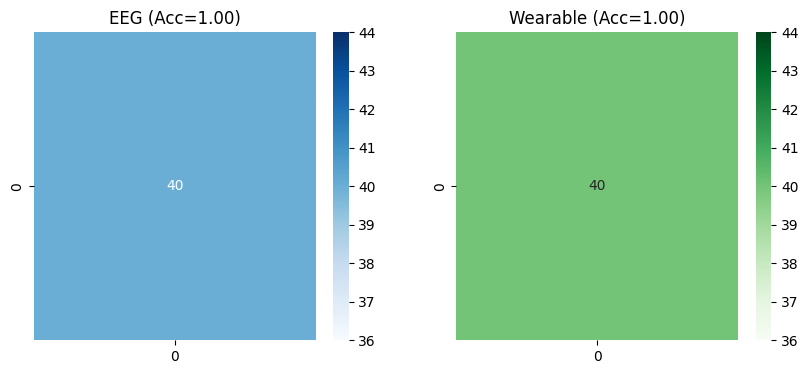

RAM 사용량: 3.91 GB / 13.61 GB


In [ ]:
# ================================================
# 4️⃣ LSTM 모델 (RAM 절약 + GPU 최적화 버전)
# ================================================
import torch, torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import psutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# LSTM 정의
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# 윈도우 함수 수정 (RAM 제한)
def make_windows(signal, fs=256, sec=5, max_windows=200):
    win = fs * sec
    X, y = [], []
    for i in range(0, len(signal) - win, win):
        seg = signal[i:i+win]
        y.append(1 if np.mean(seg) > 0.5 else 0)
        X.append(seg)
        if len(X) >= max_windows:
            break
    return np.array(X), np.array(y)

# EEG / 웨어러블 윈도우 만들기
X_eeg, y_eeg = make_windows(eeg_f)
X_wear, y_wear = make_windows(wearable)

# LSTM 학습 함수 (미니배치 & GPU)
def train_lstm(X, y, epochs=10, batch_size=32, lr=0.001):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2)
    Xtr_t = torch.tensor(Xtr[:, :, None], dtype=torch.float32).to(device)
    ytr_t = torch.tensor(ytr, dtype=torch.long).to(device)
    Xte_t = torch.tensor(Xte[:, :, None], dtype=torch.float32).to(device)
    yte_t = torch.tensor(yte, dtype=torch.long).to(device)

    model = LSTMModel().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        for i in range(0, len(Xtr_t), batch_size):
            xb = Xtr_t[i:i+batch_size]
            yb = ytr_t[i:i+batch_size]
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
        if ep % 2 == 0:
            print(f"Epoch {ep:02d} | Loss: {loss.item():.4f}")

    # 평가
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(Xte_t), dim=1).cpu().numpy()
        acc = accuracy_score(yte, preds)
        cm = confusion_matrix(yte, preds)
    return acc, cm


# 모델 실행
acc_eeg, cm_eeg = train_lstm(X_eeg, y_eeg)
acc_wear, cm_wear = train_lstm(X_wear, y_wear)

print(f"EEG accuracy: {acc_eeg:.3f}")
print(f"Wearable accuracy: {acc_wear:.3f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_eeg, annot=True, fmt='d', cmap='Blues', ax=axes[0])
sns.heatmap(cm_wear, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[0].set_title(f"EEG (Acc={acc_eeg:.2f})")
axes[1].set_title(f"Wearable (Acc={acc_wear:.2f})")
plt.show()

# 메모리 사용량 확인
ram = psutil.virtual_memory()
print(f"RAM 사용량: {ram.used/1e9:.2f} GB / {ram.total/1e9:.2f} GB")
torch.cuda.empty_cache()
